# **Evaluating Random Forest Performance**

## Objectives
* Implement and evaluate the performance of random forest regression models on real-world data
* Interpret various evaluation metrics and visualizations
* Describe the feature importances for a regression model

### Introduction
We will:

* Use the California Housing data set included in scikit-learn to predict the median house price based on various attributes
* Create a random forest regression model and evaluate its performance
* Investigate the feature importances for the model

Our goal is not to find the best regressor - it is primarily intended for you to practice interpreting modelling results in the context of a real-world problem.

---

### Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew

### Load the dataset

In [4]:
# Load the data
data = fetch_california_housing()
X, y = data.data, data.target

In [5]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

#### Split the data into Training and Test Subsets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Explore the training data

In [7]:
eda = pd.DataFrame(data=X_train, columns=data.feature_names)
eda['MedHouseVal'] = y_train
eda.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880754,28.608285,5.435235,1.096685,1426.453004,3.096961,35.643149,-119.582290,2.071947
std,1.904294,12.602499,2.387375,0.433215,1137.056380,11.578744,2.136665,2.005654,1.156226
min,0.499900,1.000000,0.888889,0.333333,3.000000,0.692308,32.550000,-124.350000,0.149990
25%,2.566700,18.000000,4.452055,1.006508,789.000000,2.428799,33.930000,-121.810000,1.198000
50%,3.545800,29.000000,5.235874,1.049286,1167.000000,2.817240,34.260000,-118.510000,1.798500
75%,4.773175,37.000000,6.061037,1.100348,1726.000000,3.280000,37.720000,-118.010000,2.651250
max,15.000100,52.000000,141.909091,25.636364,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### Target Data Distribution

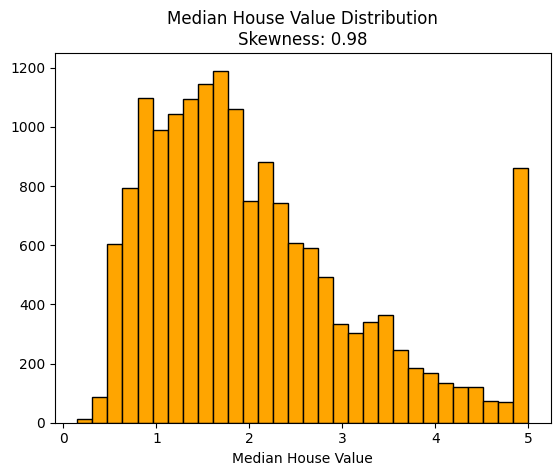

In [8]:
plt.hist(eda['MedHouseVal'], bins=30, color='orange', ec='black')
plt.title(f"Median House Value Distribution\nSkewness: {skew(eda['MedHouseVal']):.2f}")
plt.xlabel('Median House Value')
plt.show()

Evidently the distribution is skewed and there are quite a few clipped values at around $500,000

#### Model Fitting and Prediction

In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred_test = rf.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.3276
Mean Squared Error (MSE): 0.2557
Root Mean Squared Error (RMSE): 0.5057
R2 Score: 0.8049


The mean absolute error is $33,220

So, on average, predicted median house prices are off by $33k.

Mean squared error is less intiutive to interpret, but is usually what is being minimized by the model fit. On the other hand, taking the square root of MSE yields a dollar value, here RMSE = %50,630.

An R-squared score of 0.80 is not considered very high. It means the model explains about 80% of the variance in median house prices, although this interpretation can be misleading for complex data with nonlinear relationships, skewed values, and outliers. R-squared can still be useful for comparing models though.

These statistics alone don't explain any details about the performance of the models. For example, where did the model do well or poorly?

#### Plot Actual vs. Predicted Values

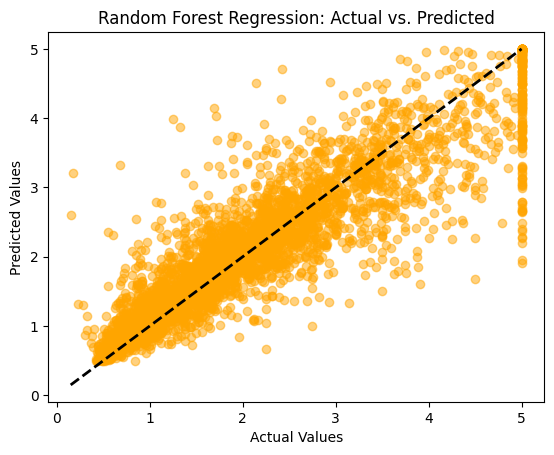

In [11]:
plt.scatter(y_test, y_pred_test, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Regression: Actual vs. Predicted")
plt.show()

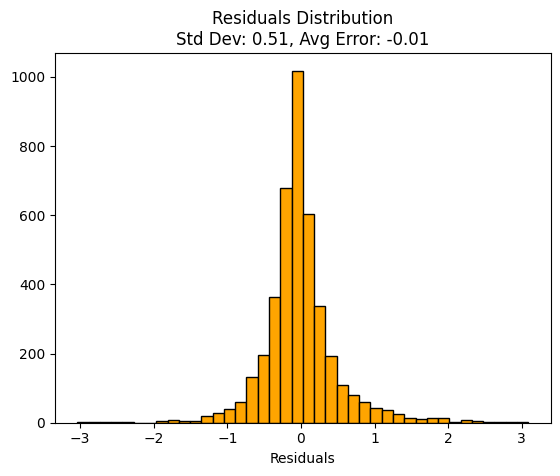

In [12]:
residuals = (y_test - y_pred_test)
residuals_std = np.std(residuals)
avg_error = np.mean(residuals)
plt.hist(residuals, bins=40, color='orange', ec='black')
plt.title(f"Residuals Distribution\nStd Dev: {residuals_std:.2f}, Avg Error: {avg_error:.2f}")
plt.xlabel('Residuals')

plt.show()

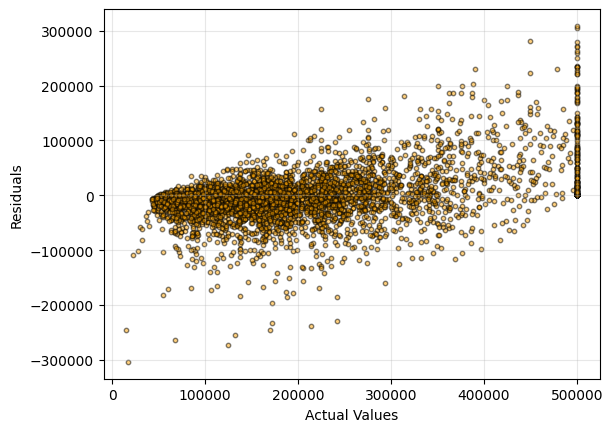

In [28]:
plt.scatter(y_test*1e5, residuals*1e5, s=10, alpha=0.5, color='orange', marker='o', ec='k')
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.grid(alpha=0.3)
plt.show()

Although we saw a small average residual of only -$1400, we can see from this plot that the average error as a function of median house price is actually increasing from negative to positive values. In other words, lower median prices tend to be overpredicted while higher median prices tend to be underpredicted.

In [25]:
# Log Transformation

y_train_log = np.log1p(y_train)
rf.fit(X_train, y_train_log)
y_pred_log = rf.predict(X_test)
y_pred_exp = np.expm1(y_pred_log)
residuals_final = y_test - y_pred_exp

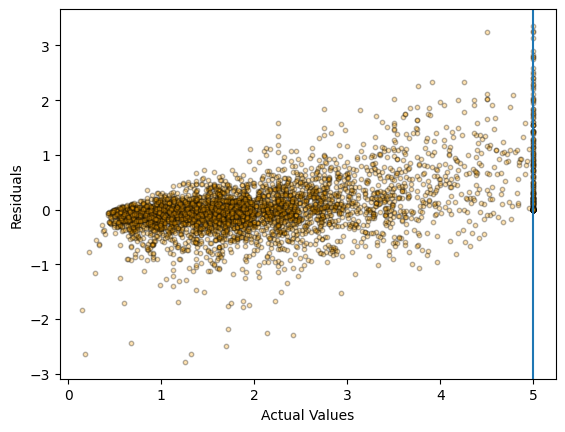

In [27]:
# Scatter
plt.scatter(y_test, residuals_final, alpha=0.3, s=10, color='orange', marker='o', ec='k')
plt.axvline(5.0)
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.show()

In [35]:
from sklearn.metrics import mean_absolute_percentage_error

mape_normal = mean_absolute_percentage_error(y_test, y_pred_test)
mape_log = mean_absolute_percentage_error(y_test, y_pred_exp)

print("MAPE before:", round(mape_normal,4))
print("MAPE log:", round(mape_log,4))

MAPE before: 0.1894
MAPE log: 0.1763


#### Feature Importances as a bar chart

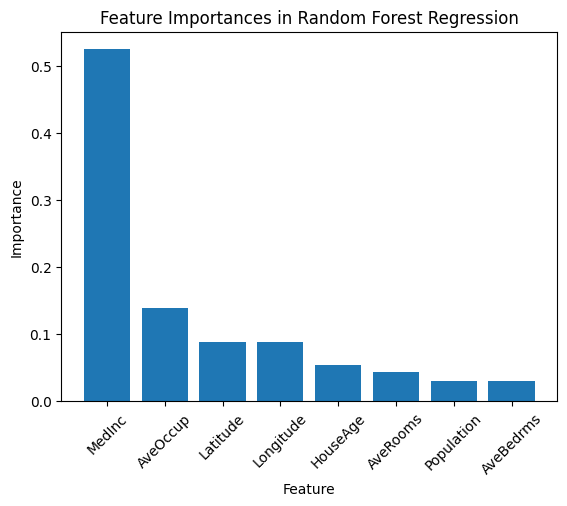

In [15]:
# Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = data.feature_names

# Plot feature importances
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importances in Random Forest Regression")
plt.show()

It makes sense that median incomes and house prices would be correlated, so it's not surprising that median income is the most important feature. I would think that location must be a significant factor.

Since location is implied by two seperate variables, latitude and longitude that share equal importances, we might speculate that location is really the second most important feature. This is becuase replacing latitude and longitude with a categorical location at an appropriate level of granularity (suburb, city, etc.) would likely have a combined lat/lng importance, which might outweigh average occupancy.

Might average occupancy and average number of bedrooms be correlated? a proper analysis of the feature set would include a correlation matrix

Compared to linear regression, random forest regression is quite robust against outliers and skewed distributions. This is because random forest regression doesn't make any assumptions about the data distribution, where linear regression performs best with normally distributed data.
Standardizing the data isn't necessary like it is for distance-based algorithms like KNN and SVMs.

Regarding the clipped values, there is no variability in those values. Removing them in preprocessing might help the model to better explain the actual variance in the data.

The clipped values can also bias the predictions. Also these clipped values can mislead evaluation metrics. As you've learned from this lab, it's crucially important for us to visualize our results.